In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

In [2]:
df = pd.read_csv('../preprocesseddata/sentiment_analysis_142651-2020-01-01_2023-04-10.csv')

In [3]:
makes = df.groupby('Make')
tesla = pd.DataFrame(makes.get_group('Tesla').reset_index(drop=True))
audi = pd.DataFrame(makes.get_group('Audi').reset_index(drop=True))
mbenz = pd.DataFrame(makes.get_group('Mercedes-Benz').reset_index(drop=True))
bmw = pd.DataFrame(makes.get_group('BMW').reset_index(drop=True))
vw = pd.DataFrame(makes.get_group('Volkswagen').reset_index(drop=True))

In [4]:
tesla = tesla.to_csv('../preprocesseddata/tesla.csv', index=False)
audi = audi.to_csv('../preprocesseddata/audi.csv', index=False)
mbenz = mbenz.to_csv('../preprocesseddata/mbenz.csv', index=False)
bmw = bmw.to_csv('../preprocesseddata/bmw.csv', index=False)
vw = vw.to_csv('../preprocesseddata/vw.csv', index=False)

### Distribution of Tweet Length

In [5]:
df.head()

,Text,Datetime,Word,Make,Model,negative sentiment score,neutral sentiment score,positive sentiment score,compound sentiment score
0,@user @user @user Definitely. R1S is a much be...,2023-04-09 23:44:47+00:00,model x,Tesla,Model X,0.017797,0.160256,0.821948,0.268050
1,"Model X Long Range Demo\nKing Of Prussia, PA\n...",2023-04-09 23:23:56+00:00,model x,Tesla,Model X,0.013023,0.474754,0.512223,0.166400
2,"Model X Long Range New\nBuena Park, CA\nPearl ...",2023-04-09 23:17:51+00:00,model x,Tesla,Model X,0.010804,0.510698,0.478498,0.155898
3,"Model X Long Range New\nCarlsbad, CA\nMidnight...",2023-04-09 23:17:50+00:00,model x,Tesla,Model X,0.008921,0.457200,0.533879,0.174986
4,"Model X Long Range Demo\nIndianapolis, IN\nSol...",2023-04-09 23:17:48+00:00,model x,Tesla,Model X,0.010660,0.462582,0.526758,0.172033


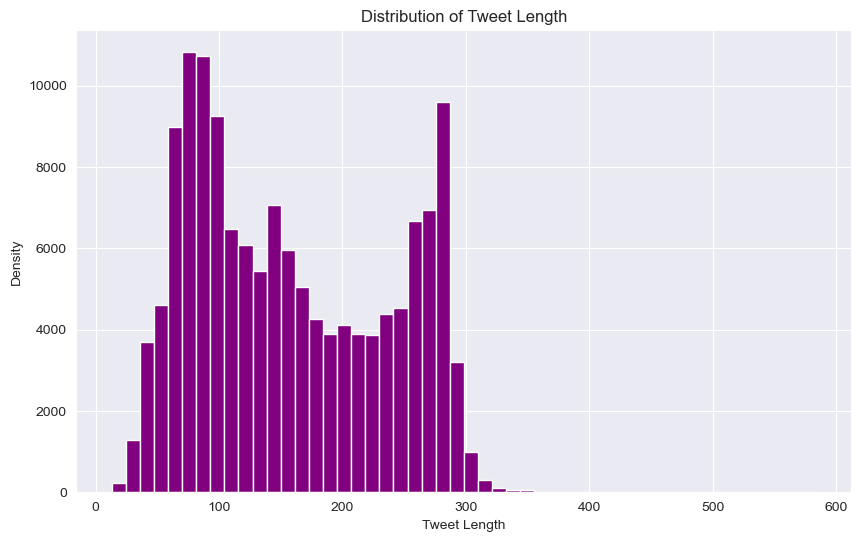

In [67]:
%matplotlib inline
plt.figure(figsize=(10,6))
df['tweet_length'] = df['Text'].apply(len)
plt.hist(df['tweet_length'], bins=50, color='purple')
plt.xlabel('Tweet Length')
plt.ylabel('Density')
plt.title('Distribution of Tweet Length')
plt.savefig('../imgs/tweet_length_distribution.png', pad_inches='tight', dpi=600)

The majority of the tweets have a length that is relatively short. This information can be useful for determining the optimal length of tweets to analyze for sentiment analysis and topic modeling. For example, it is better to focus on tweets with a length of 100 characters.
It's worth noting that the shape of the distribution of tweet length can also provide insights into the nature of the conversations around EV cars. For instance, this distribution might suggest that people tend to share brief impressions or short updates about EV cars and few lengthy tweets.

### Hashtag Analysis

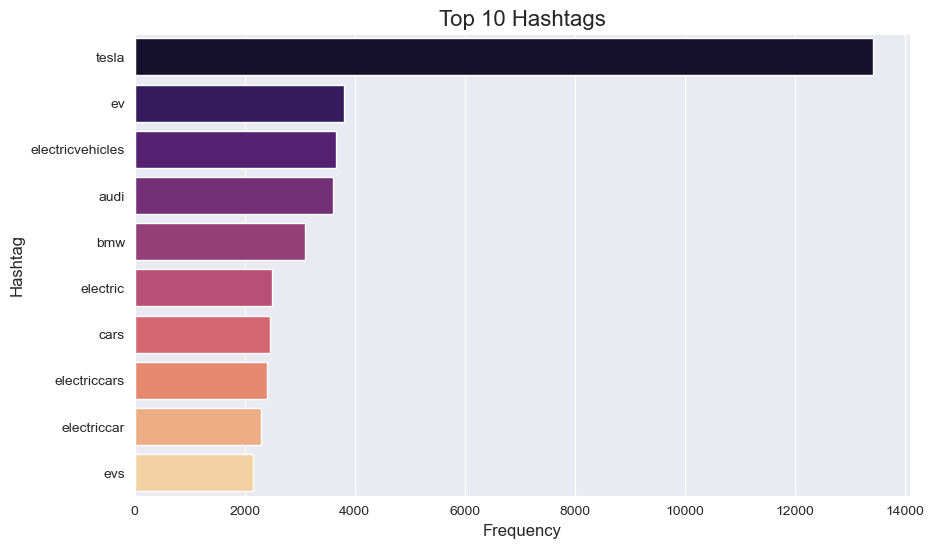

In [7]:
# Function to extract tn most commonly used hashtags and plot a bar chart

def hashtags(df, n):
    # Extract hashtags from each tweet using regular expressions
    hashtags_list = []
    for tweet in df['Text'].str.lower():
        hashtags = re.findall(r"#(\w+)", tweet)
        hashtags_list.extend(hashtags)

    # Count the frequency of each hashtag
    hashtags_count = Counter(hashtags_list)
    
    # Create a data frame of the top hashtags and their frequencies
    top_hashtags = pd.DataFrame(hashtags_count.most_common(n), columns=['Hashtag', 'Frequency'])

    #Create a bar chart of the frequency distribution of hashtags
    sns.set_style('darkgrid')
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Frequency', y='Hashtag', data=top_hashtags, palette='magma')
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Hashtag', fontsize=12)
    plt.title('Top 10 Hashtags', fontsize=16)
    
hashtags(df, 10)

plt.savefig('../imgs/hashtags.png', dpi=600)

This information can be useful for determining the topics of the tweets. 
Amazon and Aliexpress were among most commonly used hashtags which gave us this info that these tweets were mainly advertisements or they were about buying and selling parts which was kind of unrelated to our topic of research so they were dropped in data cleaning.
Now here are the new hashtags and as expected they are mainly brands and models hashtags.

count    142651.000000
mean          0.110064
std           0.156943
min          -0.326354
25%           0.017288
50%           0.128469
75%           0.241579
max           0.330885
Name: compound sentiment score, dtype: float64


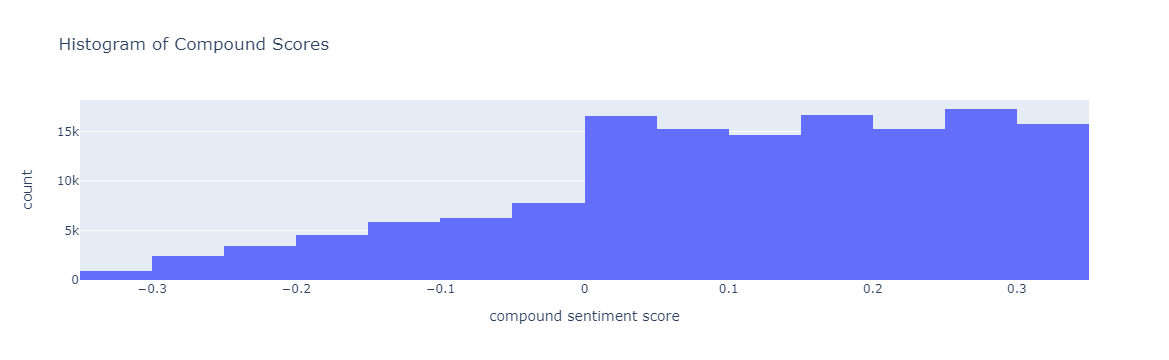

In [70]:
# Histogram of Compound Scores
import plotly.express as px
print(df['compound sentiment score'].describe())
px.histogram(df, x="compound sentiment score", nbins=30, title = 'Histogram of Compound Scores')

## Tweets Analysis over Time

### Popularoty of EV Makes on Twitter Over Time

Below, you can see the proportion of each make of car's tweets to other competitors over time.

Go ahead and select different makes from the drop down menu on the right and see the trend over time! Try it on fullscreen mode!

In [71]:
%%HTML
<div class='tableauPlaceholder' id='viz1681672375167' style='position: relative'><noscript><a href='#'><img alt='Popularoty of EV Makes on Twitter Over Time ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Po&#47;PopularityofEVMakesOverTime&#47;PopularotyofEVMakesOverTime&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='PopularityofEVMakesOverTime&#47;PopularotyofEVMakesOverTime' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Po&#47;PopularityofEVMakesOverTime&#47;PopularotyofEVMakesOverTime&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1681672375167');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

### Change of Tweets Count Over Time for each EV Brand

In [41]:
%%HTML
<div class='tableauPlaceholder' id='viz1681505226141' style='position: relative'><noscript><a href='#'><img alt='Tweet Counts - April 2023 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;EV&#47;EVCarsonTwitter&#47;TweetCounts&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='EVCarsonTwitter&#47;TweetCounts' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;EV&#47;EVCarsonTwitter&#47;TweetCounts&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1681505226141');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

### Trend of Tweets Count

In [72]:
%%HTML
<div class='tableauPlaceholder' id='viz1681672441897' style='position: relative'><noscript><a href='#'><img alt='Trend of Tweets Count ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Tr&#47;TrendofEVTweets&#47;TrendofTweetsCount&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='TrendofEVTweets&#47;TrendofTweetsCount' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Tr&#47;TrendofEVTweets&#47;TrendofTweetsCount&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1681672441897');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

## Sentiment Analysis EDA

In [8]:
pos = []
neg = []
neu = []
for score in df['compound sentiment score']:
    if score > 0:
        pos.append(score)
    elif score < 0:
        neg.append(score)
    else:
        neu.append(score)

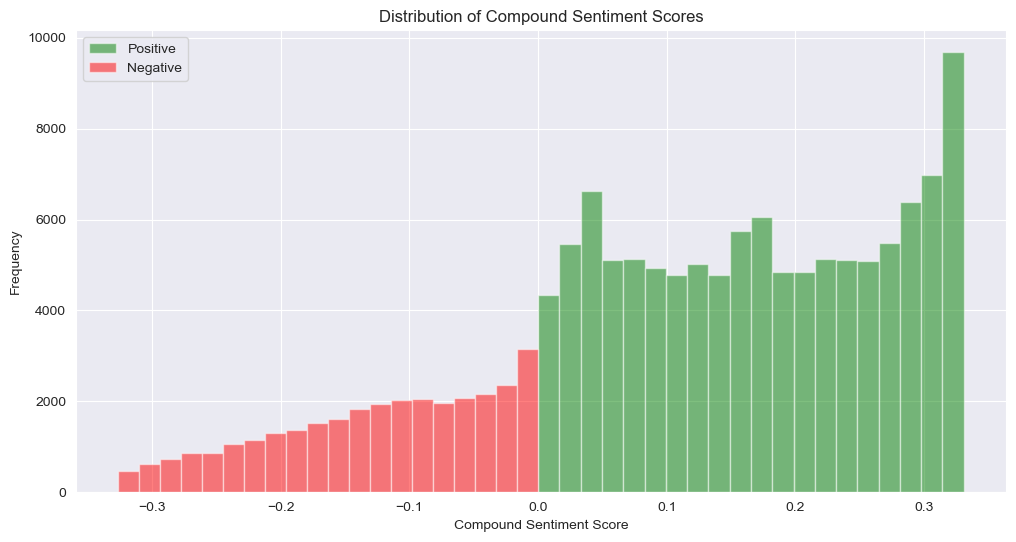

In [68]:
plt.figure(figsize=(12,6))
# Create histogram
plt.hist(pos, bins=20, color='green', alpha=0.5, label='Positive')
plt.hist(neg, bins=20, color='red', alpha=0.5, label='Negative')
# plt.hist(neu, bins=20, color='blue', alpha=0.5, label='Neutral')

# Add labels and legend
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.title('Distribution of Compound Sentiment Scores')
plt.legend();

# Save plot
plt.savefig('../imgs/Distribution_compound_sentiment_scores.png', dpi=600)

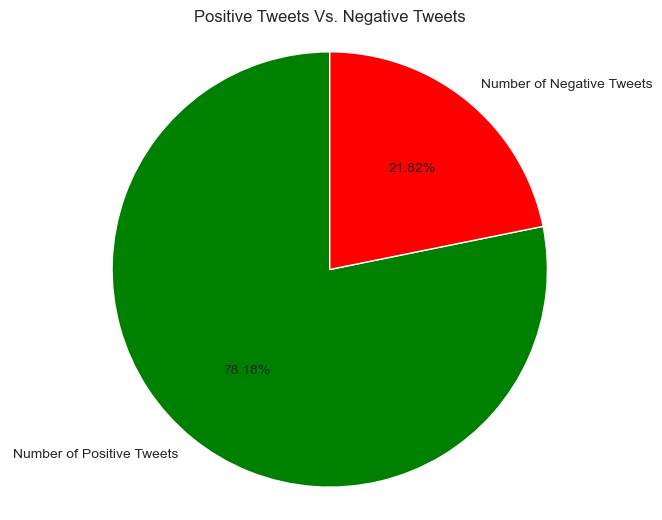

In [10]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
values = [len(pos), len(neg)]

ax.pie(values, 
       labels = ['Number of Positive Tweets', 'Number of Negative Tweets'],
       colors=['green', 'red'],
       shadow=False,
       startangle=90, 
       autopct='%1.2f%%')
ax.axis('equal')
plt.title('Positive Tweets Vs. Negative Tweets');
plt.savefig('../imgs/pos_vs._neg.png', dpi=600)

### Tweets Sentiment Score Over Time

In [74]:
%%HTML
<div class='tableauPlaceholder' id='viz1681672970552' style='position: relative'><noscript><a href='#'><img alt='Tweets Sentiment Score  Over Time ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Tw&#47;TweetsSentimentScoreOverTime&#47;TweetsSentimentScoreOverTime&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='TweetsSentimentScoreOverTime&#47;TweetsSentimentScoreOverTime' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Tw&#47;TweetsSentimentScoreOverTime&#47;TweetsSentimentScoreOverTime&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1681672970552');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

### Sentiment Score Competition

In [66]:
%%HTML
<div class='tableauPlaceholder' id='viz1681627002473' style='position: relative'><noscript><a href='#'><img alt='Sentiment Score Competition - 2022 Q2 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Se&#47;SentimentScoreCompetition&#47;SentimentScoreCompetition&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='SentimentScoreCompetition&#47;SentimentScoreCompetition' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Se&#47;SentimentScoreCompetition&#47;SentimentScoreCompetition&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1681627002473');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='100%';vizElement.style.height=(divElement.offsetWidth*0.75)+'px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

### Insights

In order to get some insights, several tweets have been looked.

In [411]:
negative_df = df[df['compound sentiment score'] < 0]

In [412]:
negative_df = negative_df.reset_index(drop=True)

In [415]:
negative_df['Text'][0]

'@user @user @user Yea. The Model X is not a good SUV. R1S runs laps around it.'

In [414]:
new = negative_df[negative_df['Datetime'] > '2022']

In [420]:
new['Text'][6]

'@user @user the model X is huge compared to the model Y.\n\nThe model Y feels tiny in comparison.'